# Practice 6 — pandas + NumPy
Work through each task in order. Try to solve it yourself before looking anything up!

In [1]:
import pandas as pd
import numpy as np

---
## Level 1 — Basics

### Task 1: Create & Summarise
1. Create a DataFrame with 6 rows representing employees. Columns: `name`, `department` (HR, Engineering, or Sales), `salary` (float), `years_exp` (integer)
2. Add a `bonus` column = 10% of salary, calculated using NumPy
3. Use `.value_counts()` on the `department` column to count how many employees are in each department

In [6]:
# 1. Create the DataFrame
data = {
    'name': ['A','B','C','D','E','F'],
    'department': ['HR','Engineering','Sales','Sales','HR','RD'],
    'salary': [400, 678.5, 400.5, 500.8, 579.3, 300],
    'years_exp': [3,4,2,5,6,9]
}
com = pd.DataFrame(data)

# 2. Add bonus column using NumPy

com['bonus'] = 0.1*com['salary'].to_numpy()
# 3. Count employees per department using .value_counts()
com['department'].value_counts()

department
HR             2
Sales          2
Engineering    1
RD             1
Name: count, dtype: int64

### Task 2: Inspect & Describe
Run the cell below to load a dataset, then:
1. Use `.info()` and `.describe()` to explore it
2. Find the mean, median, and standard deviation of `tip` using NumPy
3. Use NumPy boolean indexing to find what **percentage of tips are above the mean**

**Hint for step 3:** `(condition).mean()` on a boolean array gives the proportion.

In [7]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [14]:
# 1. Explore with .info() and .describe()

tips.describe()
tips.info()
# 2. Mean, median, std of tip
np.mean(tips['tip'])
np.median(tips['tip'])
np.nanstd(tips['tip'])

# 3. Percentage of tips above the mean
(tips['tip']>np.mean(tips['tip'])).mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


np.float64(0.4959016393442623)

### Task 3: Duplicates & Unique Values
A DataFrame with duplicate rows has been created for you.
1. Find duplicate rows using `.duplicated()`
2. Remove duplicates using `.drop_duplicates()`
3. Use `np.unique()` on the `product` column to get unique products and how many times each appears

In [17]:
# Starter data — don't change this
orders = pd.DataFrame({
    'order_id': [1, 2, 3, 2, 4, 3, 5],
    'product':  ['Apple', 'Banana', 'Apple', 'Banana', 'Orange', 'Apple', 'Banana'],
    'quantity': [2, 1, 3, 1, 2, 3, 4],
})

# 1. Find duplicate rows
orders.duplicated()

# 2. Remove duplicates

orders.drop_duplicates()
# 3. Unique products and counts using np.unique
np.unique(orders['product'],return_counts=True)

(array(['Apple', 'Banana', 'Orange'], dtype=object), array([3, 3, 1]))

---
## Level 2 — Transformations

### Task 4: Bin Data with `pd.cut()`
A DataFrame of customer ages has been created for you.
1. Use `pd.cut()` to add an `age_group` column with these bins:
   - 0–17 → `'Minor'`, 18–35 → `'Young Adult'`, 36–60 → `'Adult'`, 61–100 → `'Senior'`
2. Use `.value_counts()` on `age_group` to see how many customers fall into each group
3. Use `np.percentile()` to find the 10th, 50th, and 90th percentiles of age

In [19]:
# Starter data — don't change this
np.random.seed(7)
customers = pd.DataFrame({
    'customer_id': range(1, 21),
    'age': np.random.randint(15, 80, size=20),
})

# 1. Add age_group column using pd.cut()
customers['age_group'] = pd.cut(customers['age'], 
                                bins = [0,17,35,60,100],
                                labels= ['Minor','Young Adult','Adult','Senior'])

# 2. Count customers per age group using .value_counts()
customers['age_group'].value_counts()

# 3. 10th, 50th, 90th percentiles of age
np.percentile(customers['age'],[10,50,90])


array([21.9, 55.5, 72.3])

### Task 5: Log Transformation
Salary data is often right-skewed — a few very high earners pull the distribution. A log transformation compresses the high end and makes the data more balanced.

A DataFrame of salaries has been created for you.
1. Use `np.log()` to add a `log_salary` column (log transformation of `salary`)
2. Compare the mean and std of `salary` vs `log_salary` — notice how the std shrinks
3. Use `np.clip()` to cap `salary` between the 10th and 90th percentile, and store as `salary_clipped`
4. Use `np.where()` to add a `high_earner` column — `True` if salary > 100000, `False` otherwise

In [26]:
# Starter data — don't change this
np.random.seed(2)
staff = pd.DataFrame({
    'name':   [f'Person_{i}' for i in range(1, 11)],
    'salary': [45000, 52000, 61000, 48000, 75000, 210000, 58000, 430000, 67000, 55000],
})

# 1. Add log_salary column using np.log()
staff['log_salary'] = np.log(staff['salary'])

# 2. Compare mean and std of salary vs log_salary
staff[['salary','log_salary']].agg(['mean', 'std'])
# 3. Clip salary between 10th and 90th percentile
p10, p90 = np.percentile(staff['salary'],[10,90])
staff['salary_clipped'] = np.clip(staff['salary'],p10,p90)

# 4. Add high_earner column using np.where()
staff['higher_earner'] = np.where(staff['salary']>100000, True, False)
staff

/Users/ginny/pandas_practice/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return bound(*args, **kwds)


,name,salary,log_salary,salary_clipped,higher_earner
0,Person_1,45000,10.714418,47700,False
1,Person_2,52000,10.858999,52000,False
2,Person_3,61000,11.018629,61000,False
3,Person_4,48000,10.778956,48000,False
4,Person_5,75000,11.225243,75000,False
5,Person_6,210000,12.254863,210000,True
6,Person_7,58000,10.968198,58000,False
7,Person_8,430000,12.971540,232000,True
8,Person_9,67000,11.112448,67000,False
9,Person_10,55000,10.915088,55000,False


### Task 6: Missing Data + NumPy
A DataFrame with missing values has been created for you.
1. Show how many nulls are in each column using `.isnull().sum()`
2. Use `np.nanmean()`, `np.nanmedian()`, `np.nanstd()` on the `score` column
3. Fill missing `score` values with the nanmedian
4. Fill missing `attempts` values with the nanmean (rounded to nearest integer)

In [33]:
# Starter data — don't change this
results = pd.DataFrame({
    'student':  ['Alice', 'Bob', 'Carol', 'Dave', 'Emma', 'Frank'],
    'score':    [88.0, np.nan, 73.0, 91.0, np.nan, 65.0],
    'attempts': [1, 2, np.nan, 1, 3, np.nan],
})

# 1. Count nulls per column
results.isnull().sum()

# 2. nanmean, nanmedian, nanstd of score

np.nanmean(results['score'])
np.nanmedian(results['score'])
np.nanstd(results['score'])

# 3. Fill missing score with nanmedian
results['score'] = results['score'].fillna(np.nanmedian(results['score']))

# 4. Fill missing attempts with nanmean (rounded)
results['attempts'] = results['attempts'].fillna(round(np.nanmean(results['attempts'])))


In [34]:
results

,student,score,attempts
0,Alice,88.0,1.0
1,Bob,80.5,2.0
2,Carol,73.0,2.0
3,Dave,91.0,1.0
4,Emma,80.5,3.0
5,Frank,65.0,2.0


---
## Level 3 — Aggregation

### Task 7: GroupBy + NumPy Aggregations
Using the `transactions` DataFrame below:
1. Group by `category` and find the **total**, **mean**, and **min** amount using `.agg()`
2. Compute the cumulative sum of `amount` using `np.cumsum()`
3. Use `np.argsort()` to sort the `description` column by `amount` (lowest to highest)

In [ ]:
# Starter data — don't change this
transactions = pd.DataFrame({
    'description': ['Rent', 'Groceries', 'Salary', 'Utilities', 'Freelance', 'Dining'],
    'category':    ['Expense', 'Expense', 'Income', 'Expense', 'Income', 'Expense'],
    'amount':      [1200, 350, 4500, 180, 800, 95],
})

# 1. GroupBy category with total, mean, min
transactions.groupby('category')['amount'].agg(['sum','mean','min'])

# 2. Cumulative sum of amount
np.cumsum(transactions['amount'])

# 3. Sort description by amount using np.argsort()
transactions['description'].to_numpy()[np.argsort(transactions['amount'])]


5       Dining
3    Utilities
1    Groceries
4    Freelance
0         Rent
2       Salary
Name: description, dtype: object

In [40]:
transactions['description']

0         Rent
1    Groceries
2       Salary
3    Utilities
4    Freelance
5       Dining
Name: description, dtype: object

### Task 8: Rolling Average
A time series DataFrame has been created for you.
1. Add a `rolling_avg` column with a **5-day rolling mean** using `.rolling(5).mean()`
2. Use `np.corrcoef()` to find the correlation between `sales` and `rolling_avg` (remember to drop NaN rows first)
3. Plot both columns on the same chart

<Axes: xlabel='date'>

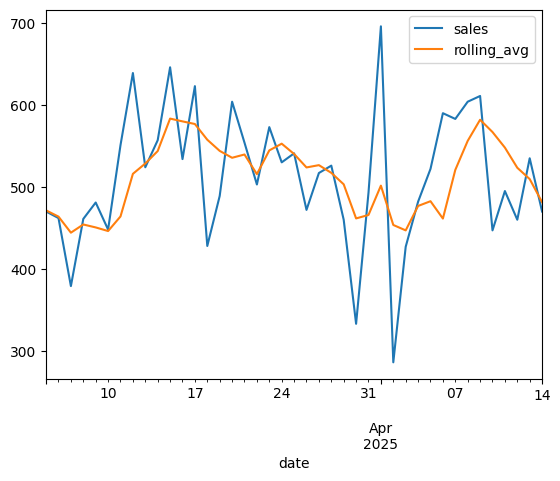

In [44]:
# Starter data — don't change this
np.random.seed(9)
dates = pd.date_range('2025-03-01', periods=45, freq='D')
store = pd.DataFrame({
    'date':  dates,
    'sales': np.random.normal(500, 80, size=45).round(0),
})
store = store.set_index('date')

# 1. Add 5-day rolling average

store['rolling_avg'] = store['sales'].rolling(5).mean()
# 2. Correlation between sales and rolling_avg
store = store.dropna()
np.corrcoef(store['sales'],store['rolling_avg'])
# 3. Plot both columns
store[['sales','rolling_avg']].plot()

### Task 9: Merge + Weighted Score
Two DataFrames are provided.
1. Merge `employees` and `reviews` on `emp_id`
2. Use `.groupby()` + `.apply()` with `np.dot()` to compute each employee's **weighted performance score** across the three criteria
3. Add the result back as a new column on the employees DataFrame

In [53]:
# Starter data — don't change this
employees = pd.DataFrame({
    'emp_id': [1, 2, 3],
    'name':   ['Alice', 'Bob', 'Carol'],
})

reviews = pd.DataFrame({
    'emp_id':    [1, 1, 1, 2, 2, 2, 3, 3, 3],
    'criteria':  ['Quality', 'Speed', 'Teamwork'] * 3,
    'score':     [90, 70, 85, 60, 95, 75, 80, 80, 90],
    'weight':    [0.5, 0.3, 0.2] * 3,
})

# 1. Merge employees and reviews
m = employees.merge(reviews, on = 'emp_id', how='inner')

# 2. Weighted score per employee using np.dot()
w = m.groupby('name').apply(lambda x: np.dot(x['weight'],x['score']))
# 3. Add result back to employees DataFrame
employees['weighted performance'] = w.to_numpy()


/var/folders/3r/5sttq01d46zg8zxyw17j5nbw0000gn/T/ipykernel_8551/1376052298.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  w = m.groupby('name').apply(lambda x: np.dot(x['weight'],x['score']))


In [56]:
w.info()

<class 'pandas.core.series.Series'>
Index: 3 entries, Alice to Carol
Series name: None
Non-Null Count  Dtype  
--------------  -----  
3 non-null      float64
dtypes: float64(1)
memory usage: 156.0+ bytes


---
## Level 4 — Real-world

### Task 10: Full Pipeline
Load the tips dataset and run a full analysis:
1. Drop any rows with missing values
2. Use `.str.contains()` to filter to only `Dinner` time rows
3. Add a `tip_pct` column = tip as a percentage of total_bill
4. Use `np.log()` to add a `log_total_bill` column
5. Group by `day` and find the mean and std of `tip_pct` using `.agg()`
6. Find the correlation between `total_bill` and `tip` using `np.corrcoef()`
7. Normalize `tip_pct` to 0–1 using min-max normalization

In [70]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)

# 1. Drop missing values

tips = tips.dropna()
# 2. Filter to Dinner only using .str.contains()
tips = tips[tips['time'].str.contains('Dinner')]

# 3. Add tip_pct column
tips['tip_pct'] = tips['tip']/tips['total_bill']

# 4. Add log_total_bill column using np.log()
tips['log_total_bill'] = np.log(tips['total_bill'])

# 5. Mean and std of tip_pct per day
tips.groupby('day')['tip_pct'].agg(['mean','std'])

# 6. Correlation between total_bill and tip

np.corrcoef(tips['total_bill'],tips['tip'])
# 7. Normalize tip_pct to 0-1

tips['norm_tip_pct'] = (tips['tip_pct']-tips['tip_pct'].min())/(tips['tip_pct'].max()-tips['tip_pct'].min())


In [72]:
w.to_numpy()

array([83. , 73.5, 82. ])

In [69]:
tips

,total_bill,tip,sex,smoker,day,time,size,tip_pct,log_total_bill,norm_tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,2.832625,0.023809
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,2.336020,0.124903
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,3.044999,0.130949
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,3.164631,0.104142
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,3.202340,0.111170
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.203927,3.368330,0.168289
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.073584,3.302481,0.037945
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088222,3.121042,0.052584
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098204,2.880321,0.062566
